In [27]:
import os
import os, sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Sequential
import torch.optim as optim
import voxelmorph as vxm
import neurite as ne
os.environ['VXM_BACKEND'] = 'pytorch'

In [28]:
os.environ.get('VXM_BACKEND')

'pytorch'

In [29]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [30]:
E1 = 1000
E2 = 1000

In [31]:
x_train = np.load('Train_3D_256_256_128_FOV_norm_data.npz')['Train']
x_train = np.transpose(x_train, (3, 0, 1, 2))
vol_shape = x_train.shape[1:]
print('train vol_shape:', vol_shape)
print('train shape:', x_train.shape)

train vol_shape: (128, 256, 256)
train shape: (59, 128, 256, 256)


In [32]:
import torch

def vxm_data_generator(x_data, batch_size):
    vol_shape = x_data.shape[1:]  # データ形状を取得
    ndims = len(vol_shape)
    
    zero_phi = np.zeros([batch_size, *vol_shape, ndims])
    
    while True:
        idx1 = np.random.randint(0, x_data.shape[0], size=batch_size)
        moving_images = x_data[idx1, ..., np.newaxis]
        idx2 = np.random.randint(0, x_data.shape[0], size=batch_size)
        fixed_images = x_data[idx2, ..., np.newaxis]

        # TensorFlowからPyTorchのデータ形式に変換
        moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
        fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()

        # チャンネルを最初の次元に追加
        moving_images = moving_images.permute(0, 1, 2, 3, 4)  # チャンネルを最初の次元に移動
        fixed_images = fixed_images.permute(0, 1, 2, 3, 4)  # チャンネルを最初の次元に移動

        inputs = [moving_images, fixed_images]
        outputs = [fixed_images, zero_phi]

        yield (inputs, outputs)

In [33]:
train_generator = vxm_data_generator(x_train, batch_size=2)
in_sample, out_sample = next(train_generator)

# in_sampleとout_sampleの内容を確認する
print("Input Sample Shapes:")
print("Moving Images Shape:", in_sample[0].shape)
print("Fixed Images Shape:", in_sample[1].shape)

print("\nOutput Sample Shapes:")
print("Moved Images (Fixed) Shape:", out_sample[0].shape)
print("Zero Gradient Shape:", out_sample[1].shape)

Input Sample Shapes:
Moving Images Shape: torch.Size([2, 1, 128, 256, 256])
Fixed Images Shape: torch.Size([2, 1, 128, 256, 256])

Output Sample Shapes:
Moved Images (Fixed) Shape: torch.Size([2, 1, 128, 256, 256])
Zero Gradient Shape: (2, 128, 256, 256, 3)


In [34]:
mse_loss = vxm.losses.NCC().loss
grad_loss = vxm.losses.Grad('l2').loss

def total_loss(y_true, y_pred):
    mse = -1 * mse_loss(y_true, y_pred)
    grad = grad_loss(y_true, y_pred)
    return mse + 50*grad, mse , 50*grad
#     return mse_loss(y_true, y_pred)

def MSE_Loss(y_true, y_pred):
    mse = mse_loss(y_true, y_pred)
    return mse

In [35]:
# mse_loss = vxm.losses.MSE().loss
# grad_loss = vxm.losses.Grad('l2').loss

# def total_loss(y_true, y_pred):
#     mse = mse_loss(y_true, y_pred)
#     grad = grad_loss(y_true, y_pred)
#     return mse + 2.5 * grad, mse, grad * 2.5
# #     return mse_loss(y_true, y_pred)

# def MSE_Loss(y_true, y_pred):
#     mse = mse_loss(y_true, y_pred)
#     return mse

In [36]:
def load_partial_state_dict(model, state_dict):
    model_dict = model.state_dict()
    pretrained_dict = {k: v for k, v in state_dict.items() if k in model_dict and model_dict[k].size() == v.size()}
    model_dict.update(pretrained_dict)
    model.load_state_dict(model_dict)

In [37]:
import torch
import torch.nn.functional as F

def gaussian_pyramid(img, num_levels=4):
    pyr = [img]
    for i in range(num_levels - 1):
        img = F.interpolate(img, scale_factor=0.5, mode='trilinear', align_corners=False)
        pyr.append(img)
    return pyr

def laplacian_pyramid(img, num_levels=4):
    pyr = gaussian_pyramid(img, num_levels)
    lap_pyr = []
    for i in range(num_levels - 1):
        up = F.interpolate(pyr[i + 1], size=pyr[i].shape[2:], mode='trilinear', align_corners=False)
        lap_pyr.append(pyr[i] - up)
    lap_pyr.append(pyr[-1])
    return lap_pyr

def laplacian_pyramid_loss(img1, img2, num_levels=4):
    pyr1 = laplacian_pyramid(img1, num_levels)
    pyr2 = laplacian_pyramid(img2, num_levels)
    
    loss = 0.0
    for l1, l2 in zip(pyr1, pyr2):
        loss += F.mse_loss(l1, l2)
    
    return loss

In [38]:
# configure unet input shape (concatenation of moving and fixed images)
ndim = 3
unet_input_features = 2
# inshape = (*x_train.shape[1:], unet_input_features)

nb_features = [
    [32, 64, 64, 64],
    [64, 64, 64, 64, 32, 16, 16]
]

In [39]:
model3D_3 = vxm.networks.VxmDense((64, 128, 128), nb_features, int_steps=0)
model3D_3.to(device)
optimizer = optim.Adam(model3D_3.parameters(), lr=1e-5)

5
6
7
6
7
6
7
6
7
8
9
10
8
9
10
8
9
10
8
9
10
11
11
11
[32, 64, 64]


In [40]:
from tqdm.notebook import tqdm

epochs = 1000
losses = []
mses = []
grads = []

# model3D_5.load_state_dict(torch.load('model_VXM_3D_weights_laplacian_Loss_4_omomi.pth', map_location=device))

for epoch in tqdm(range(epochs)):
    
    # 学習データのバッチを取得
    train_batch,_ = next(train_generator)
    moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
    fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)
    
    moving_images = torch.nn.functional.interpolate(moving_images, size=(64, 128, 128), mode='trilinear', align_corners=False)
    fixed_images = torch.nn.functional.interpolate(fixed_images, size=(64, 128, 128), mode='trilinear', align_corners=False)
    
    moving_images = moving_images.to(device)
    fixed_images = fixed_images.to(device)
    
  # 勾配を初期化
    optimizer.zero_grad()

    # 順伝播
    transformed_image, _ = model3D_3(moving_images, fixed_images)
    
    # 既存の損失を計算
    loss, mse, grad = total_loss(fixed_images, transformed_image)
    
        
    # 逆伝播
    loss.backward()
    optimizer.step()

    torch.save(model3D_3.state_dict(), 'model_VXM_3D_weights_laplacian_omomi_hukaku.pth')

        
    # エポックごとのロスを保存

    
    losses.append(loss.cpu().item())
    mses.append(mse.cpu().item())
    grads.append(grad.cpu().item())
 

    # エポックごとのロスの表示
#     print(f"Epoch {epoch+1}/{epochs}, Loss: {loss_all:.4f}")
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}, Mses: {mse}, Grad: {grad}")

  0%|          | 0/1000 [00:00<?, ?it/s]

C:\Users\user\AppData\Local\Temp\ipykernel_20408\971392900.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
C:\Users\user\AppData\Local\Temp\ipykernel_20408\971392900.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)


torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 1/1000, Loss: 0.3463, Mses: 0.25736644864082336, Grad: 0.08895173668861389
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 2/1000, Loss: 0.2886, Mses: 0.23734360933303833, Grad: 0.051260098814964294
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 3/1000, Loss: 0.3091, Mses: 0.2404291331768036, Grad: 0.06866767257452011
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 4/1000, Loss: 0.3480, Mses: 0.25582391023635864, Grad: 0.09219001233577728
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 5/1000, Loss: 0.3008, Mses: 0.23972788453102112, Grad: 0.06111493706703186
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 6/1000, Loss: 0.2996, Mses: 0.21768853068351746, Grad: 0.08192417770624161
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])
Epoch 7/1000, Loss: 0.2981, Mses: 0.2123129516839981

In [15]:
# from tqdm.notebook import tqdm

# epochs = 500
# losses = []
# mses = []
# grads = []
# laplacian_losses = []
# total_loss_values = []

# # model3D_5.load_state_dict(torch.load('model_VXM_3D_weights_laplacian_Loss_4_omomi.pth', map_location=device))

# for epoch in tqdm(range(epochs)):
    
#     # 学習データのバッチを取得
#     train_batch,_ = next(train_generator)
#     moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
#     fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)
    
#     moving_images = torch.nn.functional.interpolate(moving_images, size=(64, 128, 128), mode='trilinear', align_corners=False)
#     fixed_images = torch.nn.functional.interpolate(fixed_images, size=(64, 128, 128), mode='trilinear', align_corners=False)
    
#     moving_images = moving_images.to(device)
#     fixed_images = fixed_images.to(device)
    
#   # 勾配を初期化
#     optimizer.zero_grad()

#     # 順伝播
#     transformed_image, _ = model3D_3(moving_images, fixed_images)
    
#     # 既存の損失を計算
#     loss, mse, grad = total_loss(fixed_images, transformed_image)
    
#     # Perceptual Lossを計算
#     laplacian_loss = laplacian_pyramid_loss(transformed_image, fixed_images)
    
#     # 最終的な損失を計算 (既存の損失とPerceptual Lossを足し合わせる)
#     total_loss_value = loss + laplacian_loss
    
#     # 逆伝播
#     total_loss_value.backward()
#     optimizer.step()

#     torch.save(model3D_3.state_dict(), 'model_VXM_3D_weights_laplacian_omomi_hukaku.pth')

        
#     # エポックごとのロスを保存

    
#     losses.append(loss.cpu().item())
#     mses.append(mse.cpu().item())
#     grads.append(grad.cpu().item())
#     laplacian_losses.append(laplacian_loss.cpu().item())    
#     total_loss_values.append(total_loss_value.cpu().item())      

#     # エポックごとのロスの表示
# #     print(f"Epoch {epoch+1}/{epochs}, Loss: {loss_all:.4f}")
#     print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss_value:.4f}, Mses: {mse}, Grad: {grad}, laplacian: {laplacian_loss}")

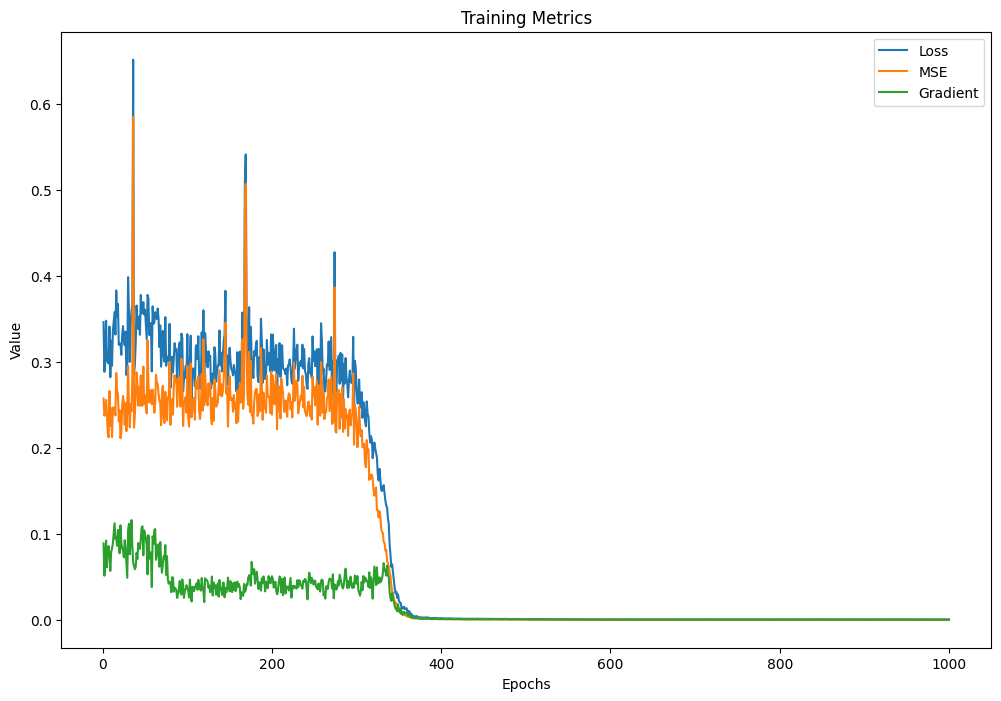

In [41]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 損失、MSE、勾配をプロット
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 8))
plt.plot(epochs_range, losses, label='Loss')
plt.plot(epochs_range, mses, label='MSE')
plt.plot(epochs_range, grads, label='Gradient')

plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('Training Metrics')
plt.legend()
plt.show()

In [17]:
import numpy as np
import matplotlib.pyplot as plt

model3D_7 = vxm.networks.VxmDense((64, 128, 128), nb_features, int_steps=0)
model3D_7.to(device)
optimizer = optim.Adam(model3D_7.parameters(), lr=1e-4)

# 学習済みモデルが既にある場合
model3D_7.load_state_dict(torch.load('model_VXM_3D_weights_laplacian_omomi_hukaku.pth', map_location=device))
# model3D_7.load_state_dict(torch.load('model_VXM_3D_weights_Adam1.pth', map_location=device))
CT1 = np.load('No6_CT1_256_256_128.npz')['Train']
CT1 = np.transpose(CT1, (3, 0, 1, 2))
print('CT1_shape:', CT1.shape)
CT2 = np.load('No6_CT2_256_256_128.npz')['Train']
CT2 = np.transpose(CT2, (3, 0, 1, 2))
print('CT2_shape:', CT2.shape)

x_val_1 = CT1[0, :, :, :]
x_val_1 = x_val_1[np.newaxis, ..., np.newaxis]
x_val_2 = CT2[0, :, :, :]
x_val_2 = x_val_2[np.newaxis, ..., np.newaxis]

batch_size = 2

idx1 = np.random.randint(0, x_val_1.shape[0], size=batch_size)
moving_images = x_val_1[idx1]
moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
moving_images11 = moving_images.permute(0, 1, 2, 3, 4)
print(moving_images11.shape)

idx2 = np.random.randint(0, x_val_2.shape[0], size=batch_size)
fixed_images = x_val_2[idx2]
fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()
fixed_images11 = fixed_images.permute(0, 1, 2, 3, 4)
print(fixed_images11.shape)

# 検証データを使って予測を行う
model3D_7.eval()  # モデルを評価モードにする
with torch.no_grad():  # 勾配計算を無効化

    moving_images = fixed_images11
    fixed_images = moving_images11

    moving_images = torch.nn.functional.interpolate(moving_images, size=(64, 128, 128), mode='trilinear', align_corners=False)
    fixed_images = torch.nn.functional.interpolate(fixed_images, size=(64, 128, 128), mode='trilinear', align_corners=False)
    
    moving_images = moving_images.to(device)
    fixed_images = fixed_images.to(device)
    transformed_image, pos_flow= model3D_7(moving_images, fixed_images)

    
# バッチから最初の画像を取得
moving_image = moving_images[0].cpu().numpy()
fixed_image = fixed_images[0].cpu().numpy()
transformed_image = transformed_image[0].cpu().numpy()
vector_field11 = pos_flow[0].cpu().numpy()

5
6
7
6
7
6
7
6
7
8
9
10
8
9
10
8
9
10
8
9
10
11
11
11
[32, 64, 64]
CT1_shape: (1, 128, 256, 256)
CT2_shape: (1, 128, 256, 256)
torch.Size([2, 1, 128, 256, 256])
torch.Size([2, 1, 128, 256, 256])
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])


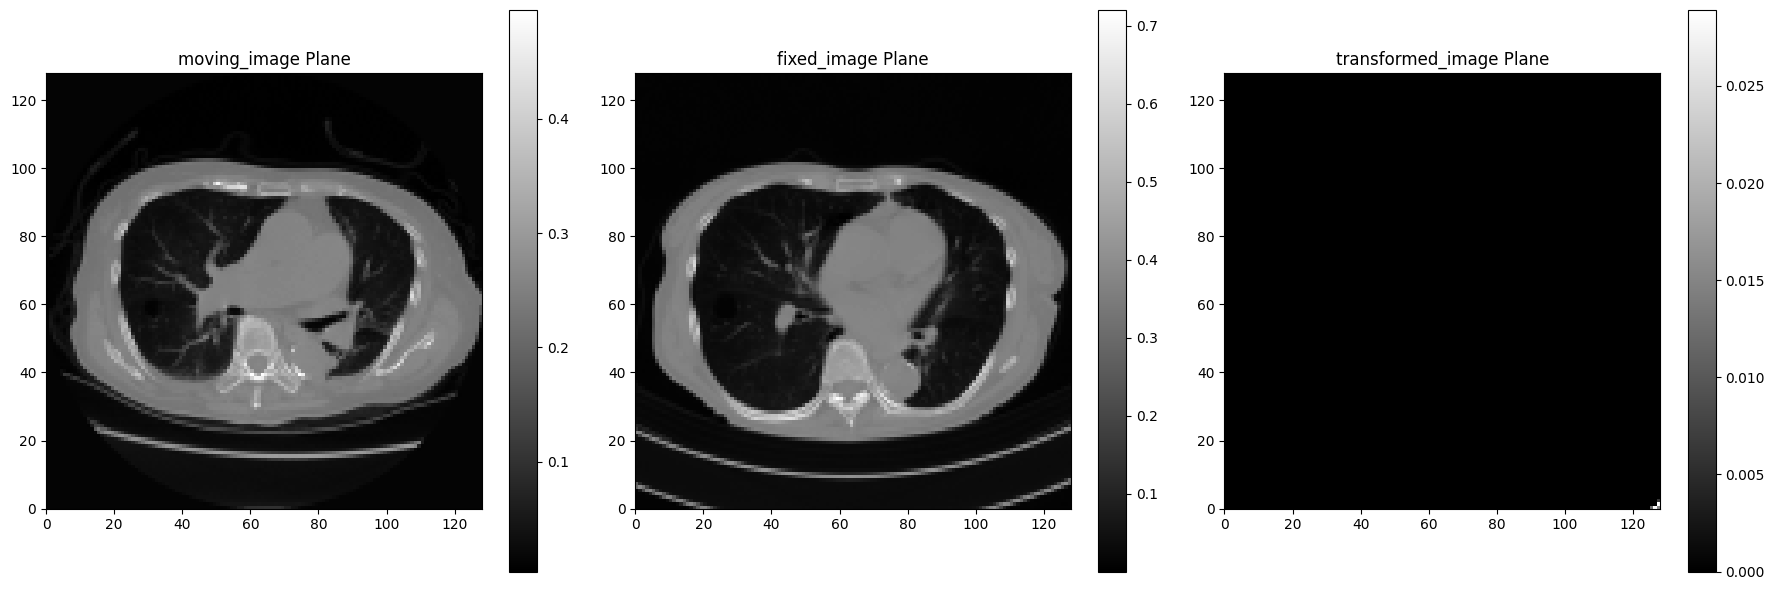

In [18]:
import numpy as np
import torch
from tifffile import imsave
plt.figure(figsize=(18, 6))  # 図のサイズを大きくする

i = 32

# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, i, :, :]
plt.imshow(A, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('moving_image Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, i, :, :]
plt.imshow(B, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('fixed_image Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
C = transformed_image[0, i, :, :]
plt.imshow(C, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('transformed_image Plane')
plt.colorbar()
    
plt.tight_layout()
plt.show()

In [43]:
print(transformed_image.max())

tensor(0.3881, device='cuda:0', grad_fn=<MaxBackward1>)


In [25]:
imsave('moving_image4.tiff', A)
imsave('fixed_image4.tiff', B)
imsave('moved_image411.tiff', C)

C:\Users\user\AppData\Local\Temp\ipykernel_20408\3761088101.py:1: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('moving_image4.tiff', A)
C:\Users\user\AppData\Local\Temp\ipykernel_20408\3761088101.py:2: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('fixed_image4.tiff', B)
C:\Users\user\AppData\Local\Temp\ipykernel_20408\3761088101.py:3: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('moved_image411.tiff', C)


In [447]:
ndim = 3
unet_input_features = 2
# inshape = (*x_train.shape[1:], unet_input_features)

nb_features = [
    [32, 64, 64, 64],
    [64, 64, 64, 64, 32, 16, 16]
]

In [35]:
model3D_3 = vxm.networks.VxmDense((32, 64, 64), nb_features, int_steps=0)
model3D_3.to(device)
optimizer = optim.Adam(model3D_3.parameters(), lr=1e-4)

5
6
7
6
7
6
7
6
7
8
9
10
8
9
10
8
9
10
8
9
10
11
11
11
[16, 32, 32]


In [36]:
from tqdm.notebook import tqdm

epochs = E1
losses = []
mses = []
grads = []
laplacian_losses = []
total_loss_values = []

# model3D_5.load_state_dict(torch.load('model_VXM_3D_weights_laplacian_Loss_4_omomi.pth', map_location=device))

for epoch in tqdm(range(epochs)):
    
    # 学習データのバッチを取得
    train_batch,_ = next(train_generator)
    moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
    fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)
    
    moving_images = torch.nn.functional.interpolate(moving_images, size=(32, 64, 64), mode='trilinear', align_corners=False)
    fixed_images = torch.nn.functional.interpolate(fixed_images, size=(32, 64, 64), mode='trilinear', align_corners=False)
    
    moving_images = moving_images.to(device)
    fixed_images = fixed_images.to(device)
    
  # 勾配を初期化
    optimizer.zero_grad()

    # 順伝播
    transformed_image, _ = model3D_3(moving_images, fixed_images)
    
    # 既存の損失を計算
    loss, mse, grad = total_loss(fixed_images, transformed_image)
    
    # Perceptual Lossを計算
    laplacian_loss = laplacian_pyramid_loss(transformed_image, fixed_images)
    
    # 最終的な損失を計算 (既存の損失とPerceptual Lossを足し合わせる)
    total_loss_value = loss + laplacian_loss
    
    # 逆伝播
    total_loss_value.backward()
    optimizer.step()

    torch.save(model3D_3.state_dict(), 'model_VXM_3D_weights_laplacian_omomi_hukaku3.pth')

        
    # エポックごとのロスを保存

    
    losses.append(loss.cpu().item())
    mses.append(mse.cpu().item())
    grads.append(grad.cpu().item())
    laplacian_losses.append(laplacian_loss.cpu().item())    
    total_loss_values.append(total_loss_value.cpu().item())      

    # エポックごとのロスの表示
#     print(f"Epoch {epoch+1}/{epochs}, Loss: {loss_all:.4f}")
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss_value:.4f}, Mses: {mse}, Grad: {grad}, laplacian: {laplacian_loss}")

  0%|          | 0/1000 [00:00<?, ?it/s]

C:\Users\user\AppData\Local\Temp\ipykernel_8220\3416756715.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
C:\Users\user\AppData\Local\Temp\ipykernel_8220\3416756715.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)


torch.Size([2, 3, 32, 64, 64])
torch.Size([2, 1, 32, 64, 64])
Epoch 1/1000, Loss: 0.0467, Mses: 0.02345031127333641, Grad: 0.003305078949779272, laplacian: 0.02318631485104561
torch.Size([2, 3, 32, 64, 64])
torch.Size([2, 1, 32, 64, 64])
Epoch 2/1000, Loss: 0.0318, Mses: 0.01572938822209835, Grad: 0.004358712583780289, laplacian: 0.01598396524786949
torch.Size([2, 3, 32, 64, 64])
torch.Size([2, 1, 32, 64, 64])
Epoch 3/1000, Loss: 0.0409, Mses: 0.02046535164117813, Grad: 0.0033744946122169495, laplacian: 0.02037350833415985
torch.Size([2, 3, 32, 64, 64])
torch.Size([2, 1, 32, 64, 64])
Epoch 4/1000, Loss: 0.0416, Mses: 0.020792920142412186, Grad: 0.0034582316875457764, laplacian: 0.020760776475071907
torch.Size([2, 3, 32, 64, 64])
torch.Size([2, 1, 32, 64, 64])
Epoch 5/1000, Loss: 0.0249, Mses: 0.012284770607948303, Grad: 0.0033279401250183582, laplacian: 0.012614795006811619
torch.Size([2, 3, 32, 64, 64])
torch.Size([2, 1, 32, 64, 64])
Epoch 6/1000, Loss: 0.0396, Mses: 0.019860621541738

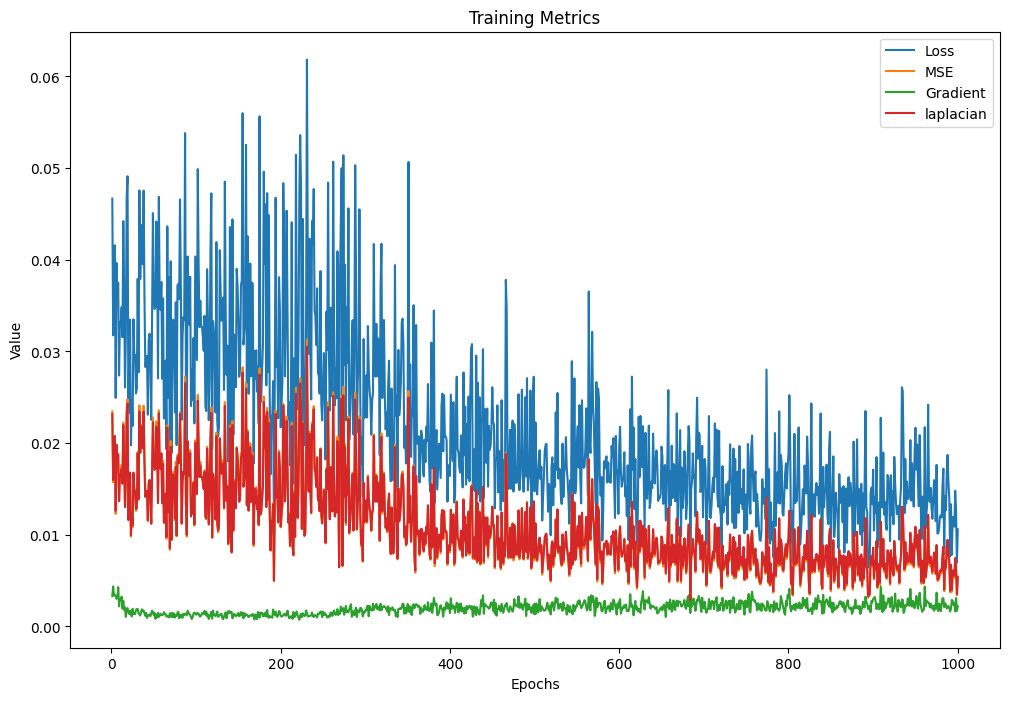

In [37]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 損失、MSE、勾配をプロット
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 8))
plt.plot(epochs_range, total_loss_values, label='Loss')
plt.plot(epochs_range, mses, label='MSE')
plt.plot(epochs_range, grads, label='Gradient')
plt.plot(epochs_range, laplacian_losses, label='laplacian')

plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('Training Metrics')
plt.legend()
plt.show()

In [38]:
import numpy as np
import matplotlib.pyplot as plt

model3D_7 = vxm.networks.VxmDense((32, 64, 64), nb_features, int_steps=0)
model3D_7.to(device)
optimizer = optim.Adam(model3D_7.parameters(), lr=1e-4)

# 学習済みモデルが既にある場合
model3D_7.load_state_dict(torch.load('model_VXM_3D_weights_laplacian_omomi_hukaku3.pth', map_location=device))
# model3D_7.load_state_dict(torch.load('model_VXM_3D_weights_Adam1.pth', map_location=device))
CT1 = np.load('No6_CT1_256_256_128.npz')['Train']
CT1 = np.transpose(CT1, (3, 0, 1, 2))
print('CT1_shape:', CT1.shape)
CT2 = np.load('No6_CT2_256_256_128.npz')['Train']
CT2 = np.transpose(CT2, (3, 0, 1, 2))
print('CT2_shape:', CT2.shape)

x_val_1 = CT1[0, :, :, :]
x_val_1 = x_val_1[np.newaxis, ..., np.newaxis]
x_val_2 = CT2[0, :, :, :]
x_val_2 = x_val_2[np.newaxis, ..., np.newaxis]

batch_size = 2

idx1 = np.random.randint(0, x_val_1.shape[0], size=batch_size)
moving_images = x_val_1[idx1]
moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
moving_images11 = moving_images.permute(0, 1, 2, 3, 4)
print(moving_images11.shape)

idx2 = np.random.randint(0, x_val_2.shape[0], size=batch_size)
fixed_images = x_val_2[idx2]
fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()
fixed_images11 = fixed_images.permute(0, 1, 2, 3, 4)
print(fixed_images11.shape)

# 検証データを使って予測を行う
model3D_7.eval()  # モデルを評価モードにする
with torch.no_grad():  # 勾配計算を無効化

    moving_images = fixed_images11
    fixed_images = moving_images11

    moving_images = torch.nn.functional.interpolate(moving_images, size=(32, 64, 64), mode='trilinear', align_corners=False)
    fixed_images = torch.nn.functional.interpolate(fixed_images, size=(32, 64, 64), mode='trilinear', align_corners=False)
    
    moving_images = moving_images.to(device)
    fixed_images = fixed_images.to(device)
    transformed_image, pos_flow= model3D_7(moving_images, fixed_images)

    
# バッチから最初の画像を取得
moving_image = moving_images[0].cpu().numpy()
fixed_image = fixed_images[0].cpu().numpy()
transformed_image = transformed_image[0].cpu().numpy()
vector_field11 = pos_flow[0].cpu().numpy()

5
6
7
6
7
6
7
6
7
8
9
10
8
9
10
8
9
10
8
9
10
11
11
11
[16, 32, 32]
CT1_shape: (1, 128, 256, 256)
CT2_shape: (1, 128, 256, 256)
torch.Size([2, 1, 128, 256, 256])
torch.Size([2, 1, 128, 256, 256])
torch.Size([2, 3, 32, 64, 64])
torch.Size([2, 1, 32, 64, 64])


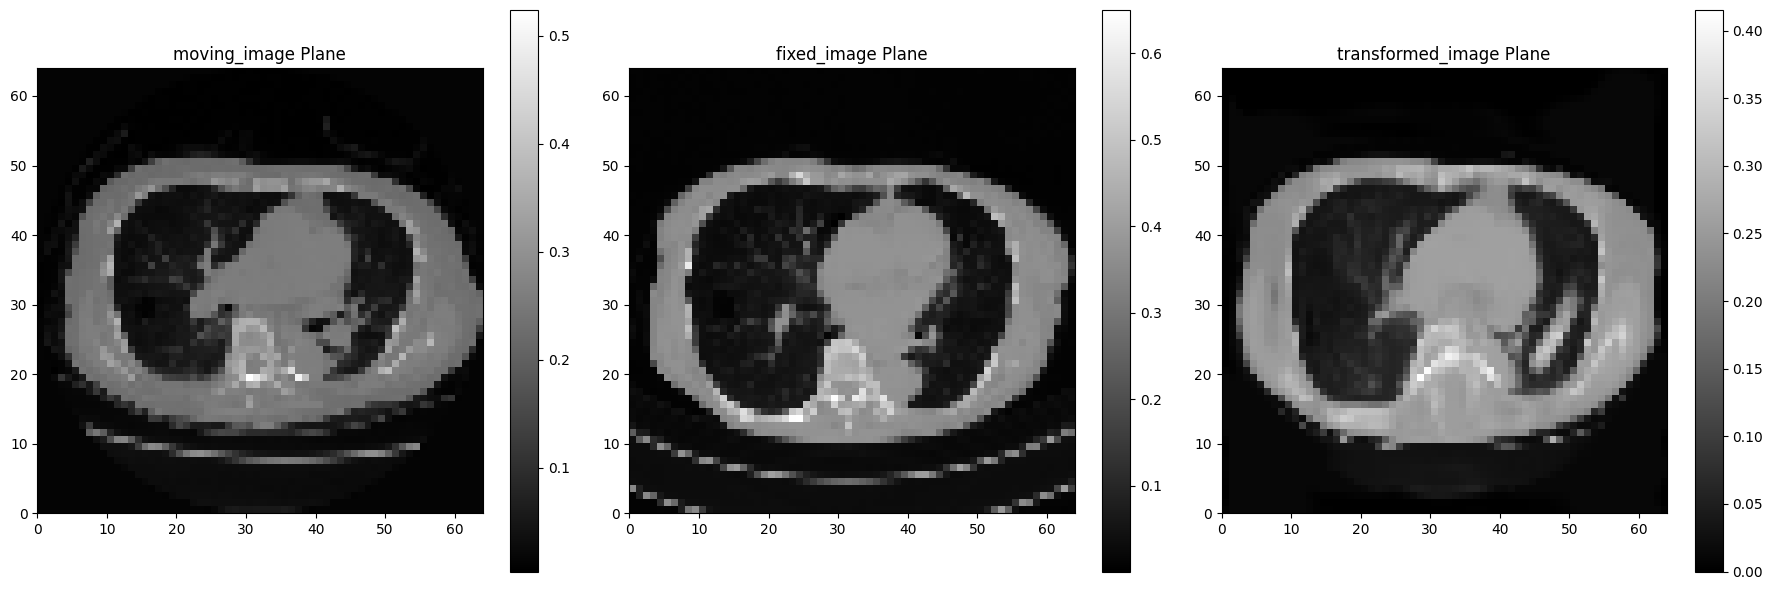

In [39]:
import numpy as np
import torch
from tifffile import imsave
plt.figure(figsize=(18, 6))  # 図のサイズを大きくする

i = 16

# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, i, :, :]
plt.imshow(A, cmap='gray', extent=[0, 64, 0, 64])  # extentで表示範囲を指定
plt.title('moving_image Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, i, :, :]
plt.imshow(B, cmap='gray', extent=[0, 64, 0, 64])  # extentで表示範囲を指定
plt.title('fixed_image Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
C = transformed_image[0, i, :, :]
plt.imshow(C, cmap='gray', extent=[0, 64, 0, 64])  # extentで表示範囲を指定
plt.title('transformed_image Plane')
plt.colorbar()
    
plt.tight_layout()
plt.show()

In [33]:
imsave('moving_image4.tiff', A)
imsave('fixed_image4.tiff', B)
imsave('moved_image411.tiff', C)

C:\Users\user\AppData\Local\Temp\ipykernel_17660\3761088101.py:1: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('moving_image4.tiff', A)
C:\Users\user\AppData\Local\Temp\ipykernel_17660\3761088101.py:2: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('fixed_image4.tiff', B)
C:\Users\user\AppData\Local\Temp\ipykernel_17660\3761088101.py:3: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('moved_image411.tiff', C)


In [25]:
def load_partial_state_dict(model, state_dict):
    model_dict = model.state_dict()
    pretrained_dict = {k: v for k, v in state_dict.items() if k in model_dict and model_dict[k].size() == v.size()}
    model_dict.update(pretrained_dict)
    model.load_state_dict(model_dict)

In [83]:
from tqdm.notebook import tqdm

epochs = E1
losses = []
mses = []
grads = []
laplacian_losses = []
total_loss_values = []

# model3D_3.load_state_dict(torch.load('model_VXM_3D_weights_laplacian_omomi_hukaku2.pth', map_location=device))
model3D_3 = vxm.networks.VxmDense((64, 128, 128), nb_features, int_steps=0)
model3D_3.to(device)
optimizer = optim.Adam(model3D_3.parameters(), lr=1e-4)
partial_weights = torch.load('model_VXM_3D_weights_laplacian_omomi_hukaku2.pth', map_location=device)
load_partial_state_dict(model3D_3, partial_weights)

for epoch in tqdm(range(epochs)):
    
    # 学習データのバッチを取得
    train_batch,_ = next(train_generator)
    moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
    fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)
    
    moving_images = torch.nn.functional.interpolate(moving_images, size=(64, 128, 128), mode='trilinear', align_corners=False)
    fixed_images = torch.nn.functional.interpolate(fixed_images, size=(64, 128, 128), mode='trilinear', align_corners=False)
    
    moving_images = moving_images.to(device)
    fixed_images = fixed_images.to(device)
    
  # 勾配を初期化
    optimizer.zero_grad()

    # 順伝播
    transformed_image, _ = model3D_3(moving_images, fixed_images)
    
    # 既存の損失を計算
    loss, mse, grad = total_loss(fixed_images, transformed_image)
    
    # Perceptual Lossを計算
    laplacian_loss = laplacian_pyramid_loss(transformed_image, fixed_images)
    
    # 最終的な損失を計算 (既存の損失とPerceptual Lossを足し合わせる)
    total_loss_value = loss + laplacian_loss
    
    # 逆伝播
    total_loss_value.backward()
    optimizer.step()

    torch.save(model3D_3.state_dict(), 'hukaku3.pth')

        
    # エポックごとのロスを保存

    
    losses.append(loss.cpu().item())
    mses.append(mse.cpu().item())
    grads.append(grad.cpu().item())
    laplacian_losses.append(laplacian_loss.cpu().item())    
    total_loss_values.append(total_loss_value.cpu().item())      

    # エポックごとのロスの表示
#     print(f"Epoch {epoch+1}/{epochs}, Loss: {loss_all:.4f}")
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss_value:.4f}, Mses: {mse}, Grad: {grad}, laplacian: {laplacian_loss}")

5
6
7
6
7
6
7
6
7
8
9
10
8
9
10
8
9
10
8
9
10
11
11
11
[32, 64, 64]


  0%|          | 0/1000 [00:00<?, ?it/s]

C:\Users\user\AppData\Local\Temp\ipykernel_17660\102092984.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
C:\Users\user\AppData\Local\Temp\ipykernel_17660\102092984.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)


Epoch 1/1000, Loss: 0.0156, Mses: 0.007798623293638229, Grad: 0.001933285384438932, laplacian: 0.007805127650499344
Epoch 2/1000, Loss: 0.0105, Mses: 0.005185931455343962, Grad: 0.0021508780773729086, laplacian: 0.005245805252343416
Epoch 3/1000, Loss: 0.0126, Mses: 0.006262003444135189, Grad: 0.0020237420685589314, laplacian: 0.006365160457789898
Epoch 4/1000, Loss: 0.0112, Mses: 0.005535894073545933, Grad: 0.002042287727817893, laplacian: 0.005628959275782108
Epoch 5/1000, Loss: 0.0178, Mses: 0.008843418210744858, Grad: 0.0023329933173954487, laplacian: 0.00895453616976738
Epoch 6/1000, Loss: 0.0258, Mses: 0.012948407791554928, Grad: 0.002985746366903186, laplacian: 0.012825516983866692
Epoch 7/1000, Loss: 0.0121, Mses: 0.005994155537337065, Grad: 0.0024707308039069176, laplacian: 0.006082451902329922
Epoch 8/1000, Loss: 0.0128, Mses: 0.006396783050149679, Grad: 0.0018605177756398916, laplacian: 0.00641589006409049


KeyboardInterrupt: 

In [628]:
import numpy as np
import matplotlib.pyplot as plt

model3D_7 = vxm.networks.VxmDense((64, 128, 128), nb_features, int_steps=0)
model3D_7.to(device)
optimizer = optim.Adam(model3D_7.parameters(), lr=1e-4)

partial_weights = torch.load('model_VXM_3D_weights_laplacian_Loss_3_omomi.pth', map_location=device)
load_partial_state_dict(model3D_7, partial_weights)

# 学習済みモデルが既にある場合
# model3D_7.load_state_dict(torch.load('model_VXM_3D_weights_laplacian_Loss_4_omomi.pth', map_location=device))
# model3D_7.load_state_dict(torch.load('model_VXM_3D_weights_Adam1.pth', map_location=device))
CT1 = np.load('No6_CT1_256_256_128.npz')['Train']
CT1 = np.transpose(CT1, (3, 0, 1, 2))
print('CT1_shape:', CT1.shape)
CT2 = np.load('No6_CT2_256_256_128.npz')['Train']
CT2 = np.transpose(CT2, (3, 0, 1, 2))
print('CT2_shape:', CT2.shape)

x_val_1 = CT1[0, :, :, :]
x_val_1 = x_val_1[np.newaxis, ..., np.newaxis]
x_val_2 = CT2[0, :, :, :]
x_val_2 = x_val_2[np.newaxis, ..., np.newaxis]

batch_size = 2

idx1 = np.random.randint(0, x_val_1.shape[0], size=batch_size)
moving_images = x_val_1[idx1]
moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
moving_images11 = moving_images.permute(0, 1, 2, 3, 4)
print(moving_images11.shape)

idx2 = np.random.randint(0, x_val_2.shape[0], size=batch_size)
fixed_images = x_val_2[idx2]
fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()
fixed_images11 = fixed_images.permute(0, 1, 2, 3, 4)
print(fixed_images11.shape)

# 検証データを使って予測を行う
model3D_7.eval()  # モデルを評価モードにする
with torch.no_grad():  # 勾配計算を無効化

    moving_images = fixed_images11
    fixed_images = moving_images11

    moving_images = torch.nn.functional.interpolate(moving_images, size=(64, 128, 128), mode='trilinear', align_corners=False)
    fixed_images = torch.nn.functional.interpolate(fixed_images, size=(64, 128, 128), mode='trilinear', align_corners=False)
    
    moving_images = moving_images.to(device)
    fixed_images = fixed_images.to(device)
    transformed_image, pos_flow= model3D_7(moving_images, fixed_images)

    
# バッチから最初の画像を取得
moving_image = moving_images[0].cpu().numpy()
fixed_image = fixed_images[0].cpu().numpy()
transformed_image = transformed_image[0].cpu().numpy()
vector_field11 = pos_flow[0].cpu().numpy()

5
6
7
6
7
6
7
6
7
8
9
10
8
9
10
8
9
10
8
9
10
11
11
11
[32, 64, 64]
CT1_shape: (1, 128, 256, 256)
CT2_shape: (1, 128, 256, 256)
torch.Size([2, 1, 128, 256, 256])
torch.Size([2, 1, 128, 256, 256])
torch.Size([2, 3, 64, 128, 128])
torch.Size([2, 1, 64, 128, 128])


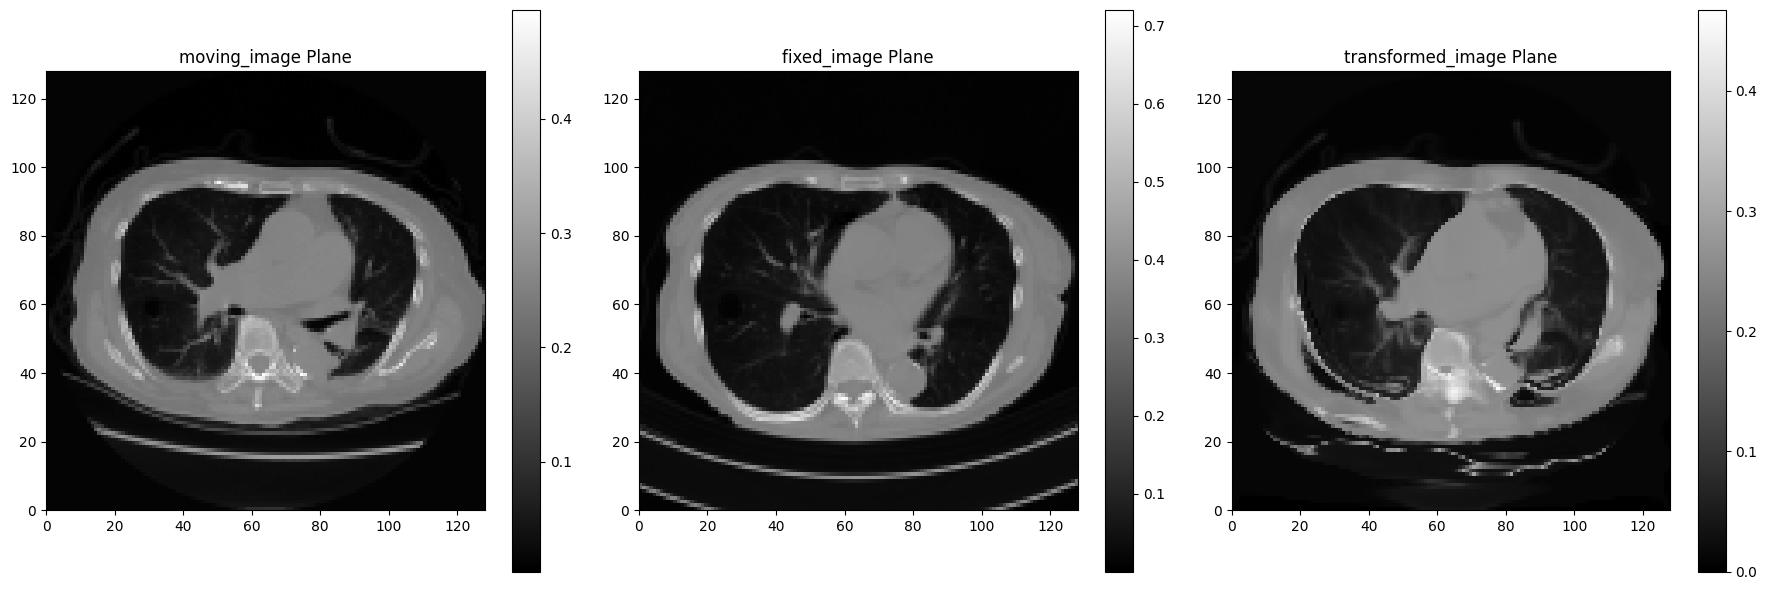

In [70]:
import numpy as np
import torch
from tifffile import imsave
plt.figure(figsize=(18, 6))  # 図のサイズを大きくする

i = 32

# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, i, :, :]
plt.imshow(A, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('moving_image Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, i, :, :]
plt.imshow(B, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('fixed_image Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
C = transformed_image[0, i, :, :]
plt.imshow(C, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('transformed_image Plane')
plt.colorbar()
    
plt.tight_layout()
plt.show()

In [68]:
# imsave('moving_image4.tiff', A)
# imsave('fixed_image4.tiff', B)
imsave('moved_image411.tiff', C)

C:\Users\user\AppData\Local\Temp\ipykernel_1732\3499825656.py:3: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('moved_image411.tiff', C)


In [71]:
import voxelmorph as vxm
print(vxm)
# moving_imagesとpos_flowを同じデバイスに移動
moving_images = moving_images.to(device)
pos_flow = pos_flow.to(device)

# transformerもデバイスに移動させる
transformer = vxm.layers.SpatialTransformer((64, 128, 128)).to(device)

# デバイスが一致した状態で呼び出す
y_source = transformer(moving_images, pos_flow)
y_source = y_source[0].cpu().numpy()



<module 'voxelmorph' from 'C:\\Users\\user\\anaconda3\\envs\\nn\\lib\\site-packages\\voxelmorph\\__init__.py'>


In [611]:
import torch

# パラメータ設定
batch_size = 2
channels = 3  # x軸, y軸, z軸
depth, height, width = 64, 128, 128
constant_value = 10

random_range = (0, 5)

# 乱数生成
pos_flow = torch.rand((batch_size, channels, depth, height, width))  # [0, 1]の範囲
pos_flow = pos_flow * (random_range[1] - random_range[0]) + random_range[0]  # [-60, 600]の範囲

# pos_flow = torch.full((batch_size, channels, depth, height, width), constant_value)

# 結果確認
print(pos_flow.size())  # torch.Size([2, 3, 64, 128, 128])
print(pos_flow.min(), pos_flow.max())  # 範囲を確認

torch.Size([2, 3, 64, 128, 128])
tensor(0.) tensor(5.0000)


In [629]:
import torch
import torch.nn.functional as F

# ガウスフィルタを適用して乱数を平滑化
def smooth_field(field, kernel_size=5, sigma=2):
    # ガウスカーネルの作成
    coords = torch.arange(kernel_size) - kernel_size // 2
    grid = torch.meshgrid(coords, coords, coords, indexing='ij')
    kernel = torch.exp(-(grid[0]**2 + grid[1]**2 + grid[2]**2) / (2 * sigma**2))
    kernel = kernel / kernel.sum()
    kernel = kernel.to(field.device)

    # カーネルの次元調整と複製
    channels = field.shape[1]
    kernel = kernel.expand(channels, 1, -1, -1, -1)  # [channels, 1, depth, height, width]

    # 畳み込みで平滑化 (バッチ全体に適用)
    field_smoothed = F.conv3d(field, kernel, padding=kernel_size // 2, groups=channels)
    return field_smoothed

# パラメータ設定
batch_size = 2
channels = 3  # x軸, y軸, z軸
depth, height, width = 64, 128, 128
random_range = (-5, 5)

# 乱数生成
pos_flow = torch.rand((batch_size, channels, depth, height, width))  # [0, 1]の範囲
pos_flow = pos_flow * (random_range[1] - random_range[0]) + random_range[0]  # [0, 5]の範囲

# 平滑化
pos_flow_smoothed = smooth_field(pos_flow)
pos_flow = pos_flow_smoothed
# 結果確認
print(pos_flow_smoothed.size())  # torch.Size([2, 3, 64, 128, 128])
print(pos_flow_smoothed.min(), pos_flow_smoothed.max())  # 範囲を確認

torch.Size([2, 3, 64, 128, 128])
tensor(-1.3078) tensor(1.2858)


In [630]:
import voxelmorph as vxm
print(vxm)
# moving_imagesとpos_flowを同じデバイスに移動
moving_images = moving_images.to(device)
pos_flow = pos_flow.to(device)

# transformerもデバイスに移動させる
transformer = vxm.layers.SpatialTransformer((64, 128, 128)).to(device)

# デバイスが一致した状態で呼び出す
y_source = transformer(moving_images, pos_flow)
y_source = y_source[0].cpu().numpy()
moving_images = moving_images[0].cpu().numpy()

<module 'voxelmorph' from 'C:\\Users\\user\\anaconda3\\envs\\nn\\lib\\site-packages\\voxelmorph\\__init__.py'>


In [631]:
fixed_image = moving_images - y_source

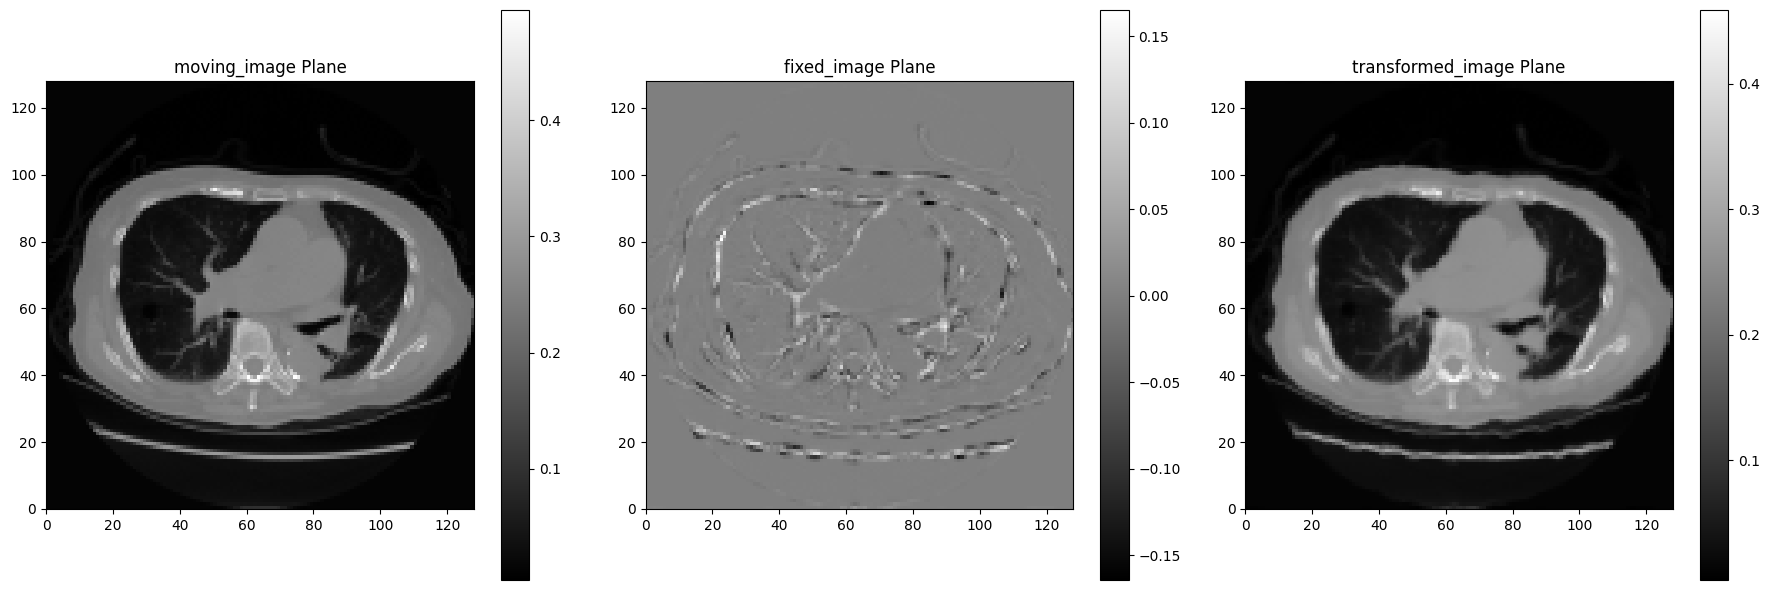

In [632]:
import numpy as np
import torch
from tifffile import imsave
plt.figure(figsize=(18, 6))  # 図のサイズを大きくする

i = 32

# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, i, :, :]
plt.imshow(A, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('moving_image Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, i, :, :]
plt.imshow(B, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('fixed_image Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
C = y_source[0, i, :, :]
plt.imshow(C, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('transformed_image Plane')
plt.colorbar()
    
plt.tight_layout()
plt.show()

In [633]:
imsave('moved_image.tiff', B)
imsave('moved_image2.tiff', C)

C:\Users\user\AppData\Local\Temp\ipykernel_8220\2348090806.py:1: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('moved_image.tiff', B)
C:\Users\user\AppData\Local\Temp\ipykernel_8220\2348090806.py:2: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('moved_image2.tiff', C)


In [77]:
print(pos_flow.min())

tensor(-31.1542, device='cuda:0')


In [80]:
print(pos_flow.max())

tensor(588.8549, device='cuda:0')


In [79]:
print(pos_flow.shape)

torch.Size([2, 3, 64, 128, 128])


In [55]:
import numpy as np
import matplotlib.pyplot as plt

model3D_7 = vxm.networks.VxmDense((32, 64, 64), nb_features, int_steps=0)
model3D_7.to(device)
optimizer = optim.Adam(model3D_7.parameters(), lr=1e-4)

# 学習済みモデルが既にある場合
model3D_7.load_state_dict(torch.load('model_VXM_3D_weights_laplacian_omomi_hukaku2.pth', map_location=device))
# model3D_7.load_state_dict(torch.load('model_VXM_3D_weights_Adam1.pth', map_location=device))
CT1 = np.load('No6_CT1_256_256_128.npz')['Train']
CT1 = np.transpose(CT1, (3, 0, 1, 2))
print('CT1_shape:', CT1.shape)
CT2 = np.load('No6_CT2_256_256_128.npz')['Train']
CT2 = np.transpose(CT2, (3, 0, 1, 2))
print('CT2_shape:', CT2.shape)

x_val_1 = CT1[0, :, :, :]
x_val_1 = x_val_1[np.newaxis, ..., np.newaxis]
x_val_2 = CT2[0, :, :, :]
x_val_2 = x_val_2[np.newaxis, ..., np.newaxis]

batch_size = 2

idx1 = np.random.randint(0, x_val_1.shape[0], size=batch_size)
moving_images = x_val_1[idx1]
moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
moving_images11 = moving_images.permute(0, 1, 2, 3, 4)
print(moving_images11.shape)

idx2 = np.random.randint(0, x_val_2.shape[0], size=batch_size)
fixed_images = x_val_2[idx2]
fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()
fixed_images11 = fixed_images.permute(0, 1, 2, 3, 4)
print(fixed_images11.shape)

# 検証データを使って予測を行う
model3D_7.eval()  # モデルを評価モードにする
with torch.no_grad():  # 勾配計算を無効化

    moving_images = fixed_images11
    fixed_images = moving_images11

    moving_images = torch.nn.functional.interpolate(moving_images, size=(32, 64, 64), mode='trilinear', align_corners=False)
    fixed_images = torch.nn.functional.interpolate(fixed_images, size=(32, 64, 64), mode='trilinear', align_corners=False)
    
    moving_images = moving_images.to(device)
    fixed_images = fixed_images.to(device)
    transformed_image, pos_flow= model3D_7(moving_images, fixed_images)

    
# バッチから最初の画像を取得
moving_image = moving_images[0].cpu().numpy()
fixed_image = fixed_images[0].cpu().numpy()
transformed_image = transformed_image[0].cpu().numpy()
vector_field11 = pos_flow[0].cpu().numpy()

5
6
7
6
7
6
7
6
7
8
9
10
8
9
10
8
9
10
8
9
10
11
11
11
[16, 32, 32]
CT1_shape: (1, 128, 256, 256)
CT2_shape: (1, 128, 256, 256)
torch.Size([2, 1, 128, 256, 256])
torch.Size([2, 1, 128, 256, 256])
torch.Size([2, 3, 32, 64, 64])
torch.Size([2, 1, 32, 64, 64])


In [56]:
import voxelmorph as vxm
print(vxm)

CT1 = np.load('No6_CT1_256_256_128.npz')['Train']
CT1 = np.transpose(CT1, (3, 0, 1, 2))
print('CT1_shape:', CT1.shape)
CT2 = np.load('No6_CT2_256_256_128.npz')['Train']
CT2 = np.transpose(CT2, (3, 0, 1, 2))
print('CT2_shape:', CT2.shape)

x_val_1 = CT1[0, :, :, :]
x_val_1 = x_val_1[np.newaxis, ..., np.newaxis]
x_val_2 = CT2[0, :, :, :]
x_val_2 = x_val_2[np.newaxis, ..., np.newaxis]

batch_size = 2

idx1 = np.random.randint(0, x_val_1.shape[0], size=batch_size)
moving_images = x_val_1[idx1]
moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
moving_images11 = moving_images.permute(0, 1, 2, 3, 4)
print(moving_images11.shape)

idx2 = np.random.randint(0, x_val_2.shape[0], size=batch_size)
fixed_images = x_val_2[idx2]
fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()
fixed_images11 = fixed_images.permute(0, 1, 2, 3, 4)
print(fixed_images11.shape)

moving_images = fixed_images11
fixed_images = moving_images11
moving_images = torch.nn.functional.interpolate(moving_images, size=(64, 128, 128), mode='trilinear', align_corners=False)
fixed_images = torch.nn.functional.interpolate(fixed_images, size=(64, 128, 128), mode='trilinear', align_corners=False)
moving_images = moving_images.to(device)

print('hhhh')
print(pos_flow.shape)
pos_flow = torch.nn.functional.interpolate(pos_flow, size=(64, 128, 128), mode='trilinear', align_corners=False)
# pos_flow = pos_flow*2
# print(pos_flow.shape)
# print(pos_flow.mean())
pos_flow = pos_flow.to(device)

# transformerもデバイスに移動させる
transformer = vxm.layers.SpatialTransformer((64, 128, 128)).to(device)

# デバイスが一致した状態で呼び出す
y_source = transformer(moving_images, pos_flow)
moving_image = moving_images[0].cpu().numpy()
y_source = y_source[0].cpu().numpy()
fixed_image = fixed_images[0].cpu().numpy()

<module 'voxelmorph' from 'C:\\Users\\user\\anaconda3\\envs\\nn\\lib\\site-packages\\voxelmorph\\__init__.py'>
CT1_shape: (1, 128, 256, 256)
CT2_shape: (1, 128, 256, 256)
torch.Size([2, 1, 128, 256, 256])
torch.Size([2, 1, 128, 256, 256])
hhhh
torch.Size([2, 3, 32, 64, 64])


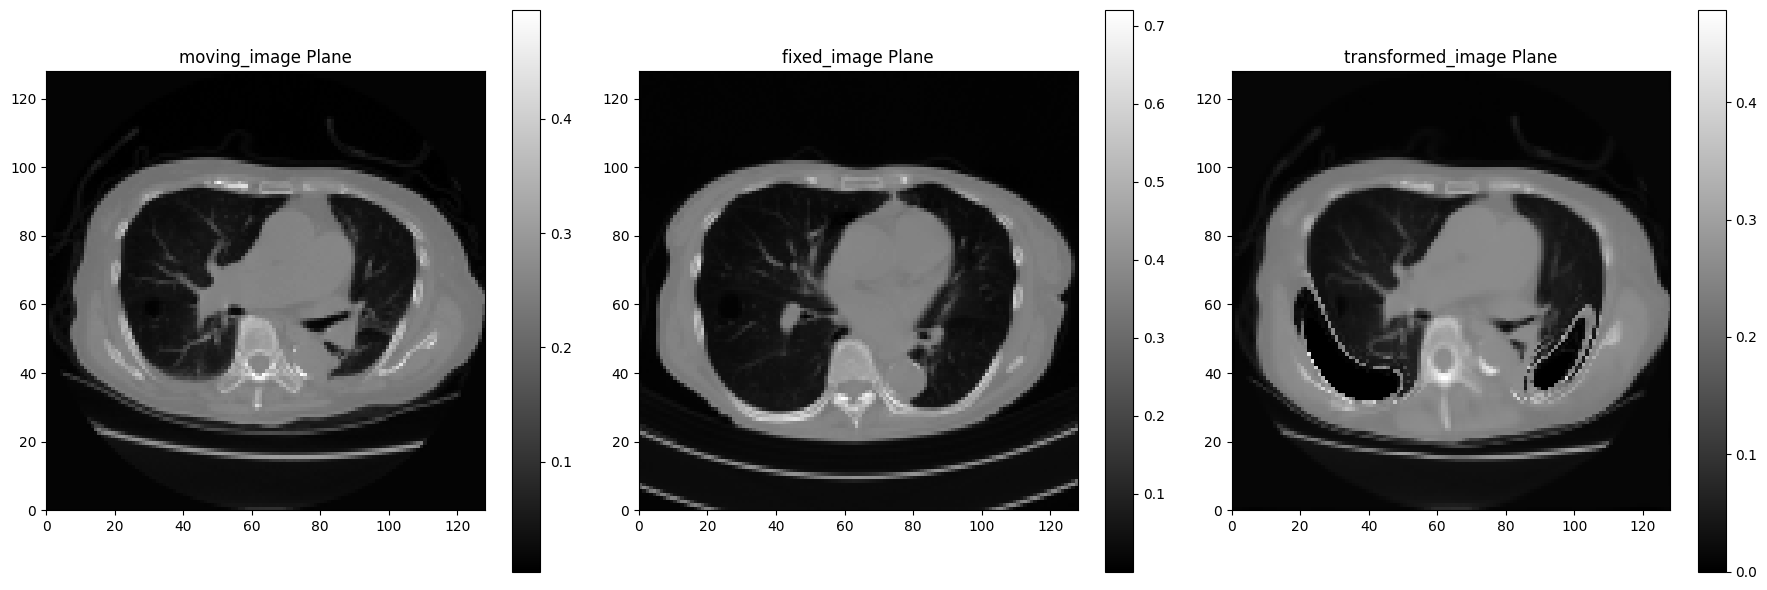

In [57]:
import numpy as np
import torch
from tifffile import imsave
plt.figure(figsize=(18, 6))  # 図のサイズを大きくする

i = 32

# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, i, :, :]
plt.imshow(A, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('moving_image Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, i, :, :]
plt.imshow(B, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('fixed_image Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
C = y_source[0, i, :, :]
plt.imshow(C, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('transformed_image Plane')
plt.colorbar()
    
plt.tight_layout()
plt.show()

In [58]:
import numpy as np
import matplotlib.pyplot as plt

model3D_7 = vxm.networks.VxmDense((32, 64, 64), nb_features, int_steps=0)
model3D_7.to(device)
optimizer = optim.Adam(model3D_7.parameters(), lr=1e-4)

# 学習済みモデルが既にある場合
model3D_7.load_state_dict(torch.load('model_VXM_3D_weights_laplacian_omomi_hukaku2.pth', map_location=device))
# model3D_7.load_state_dict(torch.load('model_VXM_3D_weights_Adam1.pth', map_location=device))
CT1 = np.load('No6_CT1_256_256_128.npz')['Train']
CT1 = np.transpose(CT1, (3, 0, 1, 2))
print('CT1_shape:', CT1.shape)
CT2 = np.load('No6_CT2_256_256_128.npz')['Train']
CT2 = np.transpose(CT2, (3, 0, 1, 2))
print('CT2_shape:', CT2.shape)

x_val_1 = CT1[0, :, :, :]
x_val_1 = x_val_1[np.newaxis, ..., np.newaxis]
x_val_2 = CT2[0, :, :, :]
x_val_2 = x_val_2[np.newaxis, ..., np.newaxis]

batch_size = 2

idx1 = np.random.randint(0, x_val_1.shape[0], size=batch_size)
moving_images = x_val_1[idx1]
moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
moving_images11 = moving_images.permute(0, 1, 2, 3, 4)
print(moving_images11.shape)

idx2 = np.random.randint(0, x_val_2.shape[0], size=batch_size)
fixed_images = x_val_2[idx2]
fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()
fixed_images11 = fixed_images.permute(0, 1, 2, 3, 4)
print(fixed_images11.shape)

# 検証データを使って予測を行う
model3D_7.eval()  # モデルを評価モードにする
with torch.no_grad():  # 勾配計算を無効化

    moving_images = fixed_images11
    fixed_images = moving_images11

    moving_images = torch.nn.functional.interpolate(moving_images, size=(32, 64, 64), mode='trilinear', align_corners=False)
    fixed_images = torch.nn.functional.interpolate(fixed_images, size=(32, 64, 64), mode='trilinear', align_corners=False)
    
    moving_images = moving_images.to(device)
    fixed_images = fixed_images.to(device)
    transformed_image, pos_flow= model3D_7(moving_images, fixed_images)

    
# バッチから最初の画像を取得
moving_image = moving_images[0].cpu().numpy()
fixed_image = fixed_images[0].cpu().numpy()
transformed_image = transformed_image[0].cpu().numpy()
vector_field11 = pos_flow[0].cpu().numpy()

5
6
7
6
7
6
7
6
7
8
9
10
8
9
10
8
9
10
8
9
10
11
11
11
[16, 32, 32]
CT1_shape: (1, 128, 256, 256)
CT2_shape: (1, 128, 256, 256)
torch.Size([2, 1, 128, 256, 256])
torch.Size([2, 1, 128, 256, 256])
torch.Size([2, 3, 32, 64, 64])
torch.Size([2, 1, 32, 64, 64])


In [59]:
import voxelmorph as vxm
print(vxm)

CT1 = np.load('No6_CT1_256_256_128.npz')['Train']
CT1 = np.transpose(CT1, (3, 0, 1, 2))
print('CT1_shape:', CT1.shape)
CT2 = np.load('No6_CT2_256_256_128.npz')['Train']
CT2 = np.transpose(CT2, (3, 0, 1, 2))
print('CT2_shape:', CT2.shape)

x_val_1 = CT1[0, :, :, :]
x_val_1 = x_val_1[np.newaxis, ..., np.newaxis]
x_val_2 = CT2[0, :, :, :]
x_val_2 = x_val_2[np.newaxis, ..., np.newaxis]

batch_size = 2

idx1 = np.random.randint(0, x_val_1.shape[0], size=batch_size)
moving_images = x_val_1[idx1]
moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
moving_images11 = moving_images.permute(0, 1, 2, 3, 4)
print(moving_images11.shape)

idx2 = np.random.randint(0, x_val_2.shape[0], size=batch_size)
fixed_images = x_val_2[idx2]
fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()
fixed_images11 = fixed_images.permute(0, 1, 2, 3, 4)
print(fixed_images11.shape)

moving_images = fixed_images11
fixed_images = moving_images11
moving_images = torch.nn.functional.interpolate(moving_images, size=(64, 128, 128), mode='trilinear', align_corners=False)
fixed_images = torch.nn.functional.interpolate(fixed_images, size=(64, 128, 128), mode='trilinear', align_corners=False)
moving_images = moving_images.to(device)

print('hhhh')
print(pos_flow.shape)
pos_flow = torch.nn.functional.interpolate(pos_flow, size=(64, 128, 128), mode='trilinear', align_corners=False)
pos_flow = pos_flow*2
print(pos_flow.shape)
print(pos_flow.mean())
pos_flow = pos_flow.to(device)

# transformerもデバイスに移動させる
transformer = vxm.layers.SpatialTransformer((64, 128, 128)).to(device)

# デバイスが一致した状態で呼び出す
y_source = transformer(moving_images, pos_flow)
moving_image = moving_images[0].cpu().numpy()
y_source = y_source[0].cpu().numpy()
fixed_image = fixed_images[0].cpu().numpy()

<module 'voxelmorph' from 'C:\\Users\\user\\anaconda3\\envs\\nn\\lib\\site-packages\\voxelmorph\\__init__.py'>
CT1_shape: (1, 128, 256, 256)
CT2_shape: (1, 128, 256, 256)
torch.Size([2, 1, 128, 256, 256])
torch.Size([2, 1, 128, 256, 256])
hhhh
torch.Size([2, 3, 32, 64, 64])
torch.Size([2, 3, 64, 128, 128])
tensor(-1.1315, device='cuda:0')


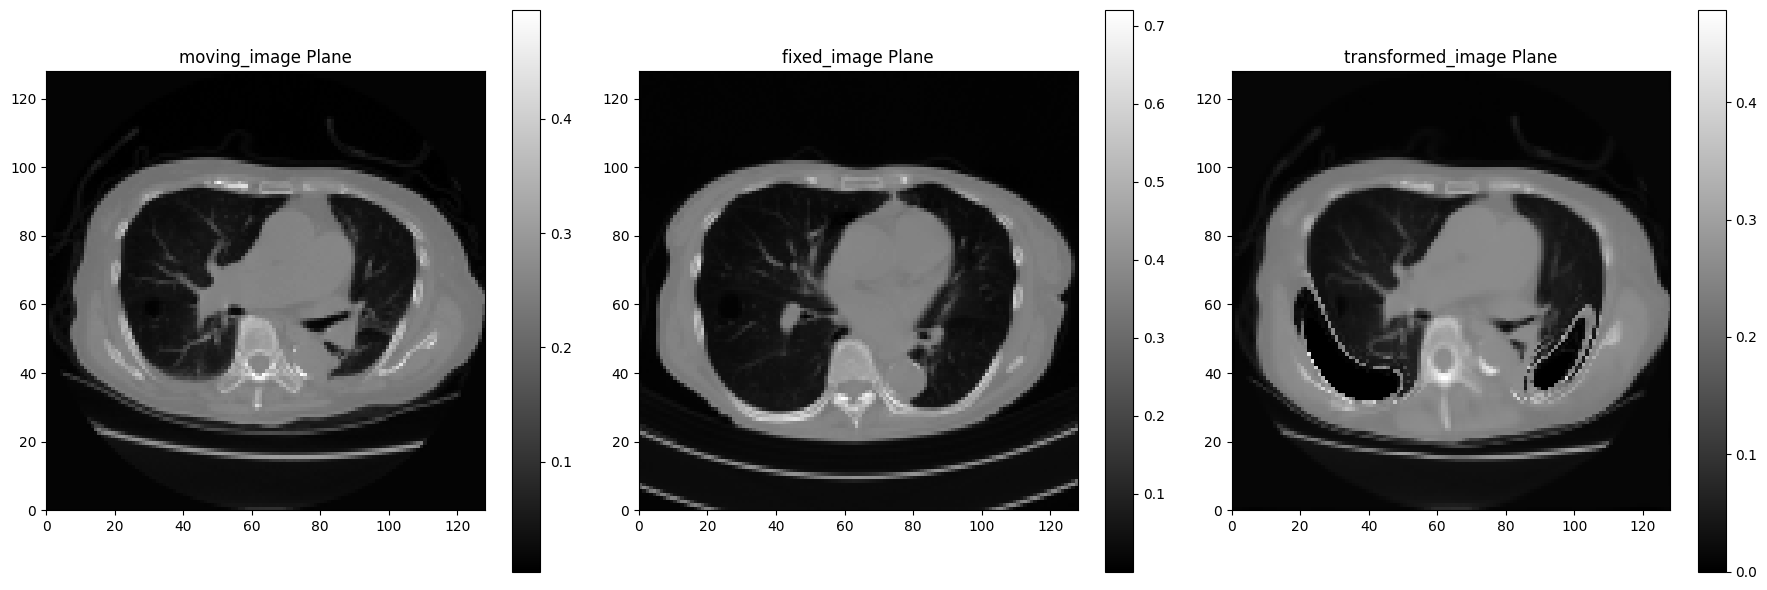

In [60]:
import numpy as np
import torch
from tifffile import imsave
plt.figure(figsize=(18, 6))  # 図のサイズを大きくする

i = 32

# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, i, :, :]
plt.imshow(A, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('moving_image Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, i, :, :]
plt.imshow(B, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('fixed_image Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
D = y_source[0, i, :, :]
plt.imshow(C, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('transformed_image Plane')
plt.colorbar()
    
plt.tight_layout()
plt.show()

In [64]:
imsave('moved_image411.tiff', C)

C:\Users\user\AppData\Local\Temp\ipykernel_1732\2668597711.py:1: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('moved_image411.tiff', C)


In [61]:
E = C-D

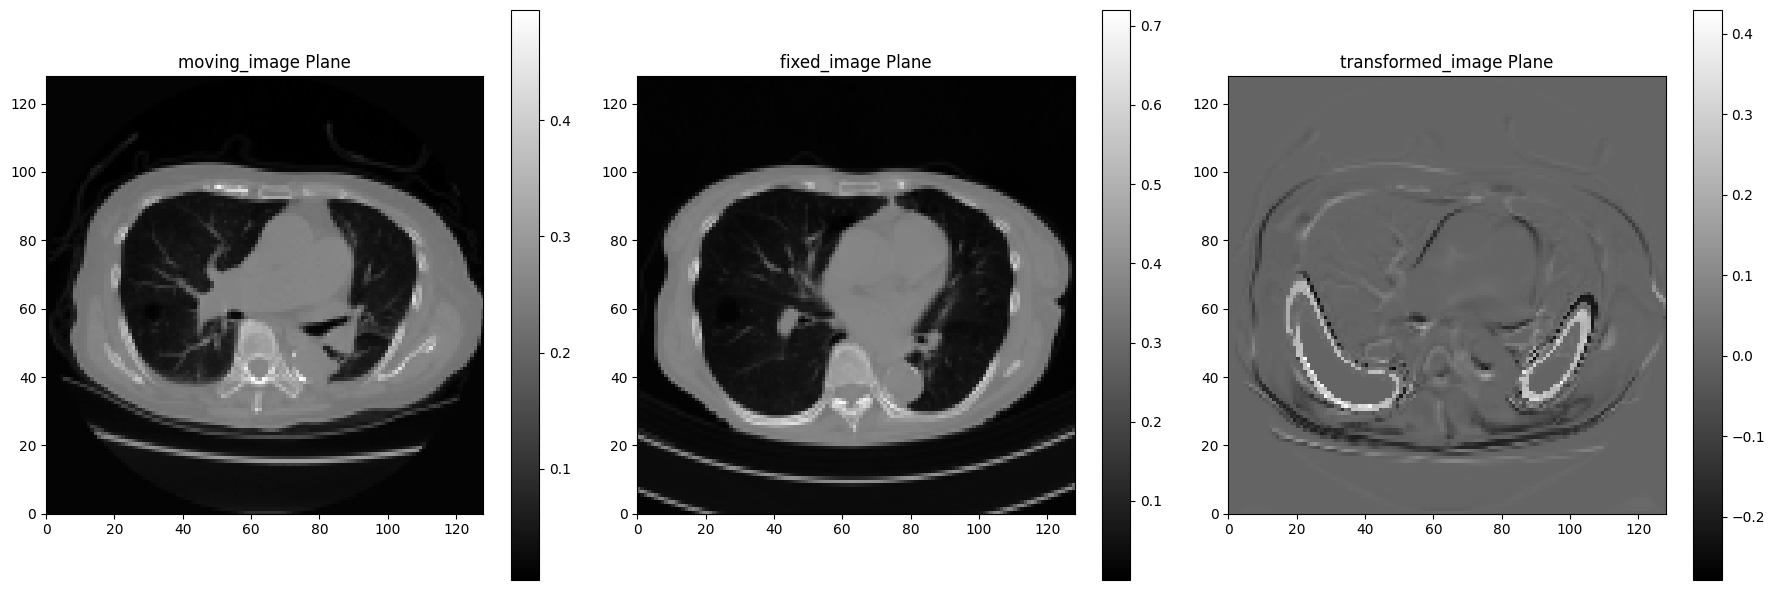

In [62]:
import numpy as np
import torch
from tifffile import imsave
plt.figure(figsize=(18, 6))  # 図のサイズを大きくする

i = 32

# moving_imageの表示32￥
plt.subplot(131)
A = moving_image[0, i, :, :]
plt.imshow(A, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('moving_image Plane')
plt.colorbar()

# fixed_imageの表示
plt.subplot(132)
B = fixed_image[0, i, :, :]
plt.imshow(B, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('fixed_image Plane')
plt.colorbar()
    
# transformed_imageの表示
plt.subplot(133)
D = y_source[0, i, :, :]
plt.imshow(E, cmap='gray', extent=[0, 128, 0, 128])  # extentで表示範囲を指定
plt.title('transformed_image Plane')
plt.colorbar()
    
plt.tight_layout()
plt.show()

In [65]:
imsave('moved_image411.tiff', E)

C:\Users\user\AppData\Local\Temp\ipykernel_1732\2857285332.py:1: DeprecationWarning: <tifffile.imsave> is deprecated. Use tifffile.imwrite
  imsave('moved_image411.tiff', E)
